In [1]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from config import coordonate_extinse


from sklearn.linear_model import Lasso, LinearRegression, Ridge, RidgeCV

from sklearn import metrics
from sklearn.ensemble import AdaBoostRegressor, ExtraTreesRegressor, RandomForestRegressor, StackingRegressor, VotingRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.tree import DecisionTreeRegressor

import xgboost as xgb
from scipy.stats import uniform, randint

from category_encoders import BinaryEncoder

from sklearn.model_selection import TimeSeriesSplit

 

c:\Users\apop3\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Descarcam datasetul.

In [2]:
# Download latest version
path = kagglehub.dataset_download("raghavramasamy/crop-statistics-fao-all-countries")

print("Path to dataset files:", path)

100%|██████████| 24.3M/24.3M [00:02<00:00, 11.3MB/s]

Extracting files...


Path to dataset files: C:\Users\apop3\.cache\kagglehub\datasets\raghavramasamy\crop-statistics-fao-all-countries\versions\3


Pastram doar datele pentru mere.

In [20]:
# 1. Încarcă fișierul original (asigură-te că folosești encoding-ul corect)
df = pd.read_csv("Crops_AllData_Normalized.csv", encoding='latin-1')

# 2. Filtrează strict pentru Mere
# Folosim .str.contains pentru a fi siguri că prindem orice variație (ex: "Apples")
df_mere = df[df['Item'] == 'Apples']

# 3. Salvează noul dataset într-un fișier CSV separat
# Folosim encoding='utf-8-sig' pentru a ne asigura că Excel îl deschide corect ulterior
df_mere.to_csv("FAO_Mere_Global.csv", index=False, encoding='utf-8-sig')

print("Filtrare finalizată! Fișierul 'FAO_Mere_Global.csv' a fost creat.")
print(f"Număr total de înregistrări salvate: {len(df_mere)}")

Filtrare finalizată! Fișierul 'FAO_Mere_Global.csv' a fost creat.
Număr total de înregistrări salvate: 19022


Verificam cate valori null avem si pe ce coloana sunt acestea.

In [16]:
df.isnull().sum()

Area                          0
Year                          0
Area harvested                0
Production                    0
Yield                         0
Temp_Medie_An                 0
Precip_Tot_An                 0
Zile_Inghet_An                0
Temp_Max_primavara_critica    0
Precip_primavara_critica      0
Inghet_primavara_critica      0
Umid_Sol_primavara_critica    0
Temp_Max_vara_crestere        0
Precip_vara_crestere          0
Inghet_vara_crestere          0
Umid_Sol_vara_crestere        0
dtype: int64

Verificam pentru ce ani se poate face interpolare. 

In [16]:
df_mere = pd.read_csv("FAO_Mere_Global.csv", encoding='utf-8-sig')

# Presupunem că df_mere este datasetul tău
# Sortăm datele după zonă și an pentru a avea serii cronologice corecte
df_mere = df_mere.sort_values(['Area', 'Year'])

# Verificăm unde avem valori nule care NU pot fi interpolate (cele de la începutul seriei fiecărei țări)
def verifica_neinterpolabile(seria):
    # Interpolăm temporar
    interp = seria.interpolate(method='linear')
    # Returnăm True acolo unde era NaN și a rămas NaN după interpolare
    return seria.isna() & interp.isna()

df_mere['is_unfixable'] = df_mere.groupby('Area')['Value'].transform(verifica_neinterpolabile)

# Vedem care este ultimul an din tot datasetul care are astfel de probleme
ultimul_an_problematic = df_mere[df_mere['is_unfixable'] == True]['Year'].max()

print(f"Până în anul {ultimul_an_problematic} avem date care nu pot fi "
      "reparate prin interpolare (lipsesc de la începutul seriilor).")

Până în anul 2004 avem date care nu pot fi reparate prin interpolare (lipsesc de la începutul seriilor).


Eliminam anii pentru care nu se poate face interpolare.

In [ ]:
df_mere = pd.read_csv("Dataset_Mere.csv", encoding='utf-8-sig')

df_mere = df_mere[df_mere['Year'] > 2004]

df_mere.to_csv("Dataset_Mere_Curat.csv", index=False, encoding='utf-8-sig')

Eliminam coloanele care nu aduc nicio informatie utila. 

In [ ]:
df_mere.drop(columns=['Area Code', 'Item Code', 'Element Code', 'Year Code', 'Item', 'Flag'], inplace=True)


# 4. Salvăm noul dataset
df_mere.to_csv("Dataset_Mere_Final.csv", index=False, encoding='utf-8-sig')


In [31]:
df_mere.isnull().sum()

Area       0
Element    0
Year       0
Unit       0
Value      0
dtype: int64

Punem tipul de masurare a valorii in coloane separate. Area harvested, production, etc.

In [ ]:
# Transformă tabelul pentru ML (un singur rând pentru fiecare țară și an)
df_final = df_mere.pivot_table(
    index=['Area', 'Year'], 
    columns='Element', 
    values='Value'
).reset_index()

# Salvează varianta gata de antrenare
df_final.to_csv("Dataset_Mere_Final.csv", index=False, encoding='utf-8-sig')

Am verificat ce zone lipsesc din dictionarul de coordonate.

In [ ]:
tari_in_dataset = set(df_final["Area"].unique())
tari_cu_coords  = set(coordonate_extinse.keys())

lipsa = tari_in_dataset - tari_cu_coords
print(f"Îți lipsesc {len(lipsa)} regiuni/țări:")
for t in sorted(lipsa):
    print(f"  - {t}")

Verificam diferneta dintre numele zonelor din dictionarul cu coordonate si numele din datasetul nostru

In [ ]:
perechi_de_verificat = ["Syria", "Moldova", "Bolivia", "Korea", "China", "United Kingdom"]

for termen in perechi_de_verificat:
    rezultate = [x for x in df_final["Area"].unique() if termen in x]
    print(f"{termen}: {rezultate}")

In scriptul "clima" am extras datele de clima pentru regiunile pe care am decis sa le pastrez si am dat merge cu datasetul de productie.


Verificam valorile nulle si duplicatele in noul dataset.

In [2]:
df = pd.read_csv("Dataset_Mere_Clima_Final.csv", encoding='utf-8-sig')

# Verificăm dacă avem valori nule în coloanele relevante
print(df.isnull().sum())

Area                           0
Year                           0
Area harvested                15
Production                     0
Yield                         15
Temp_Medie_An                  0
Precip_Tot_An                  0
Zile_Inghet_An                 0
Temp_Max_primavara_critica     0
Precip_primavara_critica       0
Inghet_primavara_critica       0
Umid_Sol_primavara_critica     0
Temp_Max_vara_crestere         0
Precip_vara_crestere           0
Inghet_vara_crestere           0
Umid_Sol_vara_crestere         0
dtype: int64


Verificam daca exista duplicate in setul de date.

In [3]:
# Numără câte rânduri sunt duplicate complet
print(f"Număr rânduri duplicate: {df.duplicated().sum()}")

# Afișează rândurile duplicate (pentru a le vedea)
print(df[df.duplicated()])

Număr rânduri duplicate: 0
Empty DataFrame
Columns: [Area, Year, Area harvested, Production, Yield, Temp_Medie_An, Precip_Tot_An, Zile_Inghet_An, Temp_Max_primavara_critica, Precip_primavara_critica, Inghet_primavara_critica, Umid_Sol_primavara_critica, Temp_Max_vara_crestere, Precip_vara_crestere, Inghet_vara_crestere, Umid_Sol_vara_crestere]
Index: []


Eliminam randurile cu valori null si mai verific odata.


In [4]:
df.dropna(subset=['Area harvested', 'Yield'], inplace=True)

df.isnull().sum()

Area                          0
Year                          0
Area harvested                0
Production                    0
Yield                         0
Temp_Medie_An                 0
Precip_Tot_An                 0
Zile_Inghet_An                0
Temp_Max_primavara_critica    0
Precip_primavara_critica      0
Inghet_primavara_critica      0
Umid_Sol_primavara_critica    0
Temp_Max_vara_crestere        0
Precip_vara_crestere          0
Inghet_vara_crestere          0
Umid_Sol_vara_crestere        0
dtype: int64

Verificam ce procent de valori de '0' avem pe fiecare coloana.

In [5]:
# Calculăm procentul de zerouri pentru fiecare coloană
zeros_report = (df == 0).sum() / len(df) * 100
print("Procentul de valori 0 în fiecare coloană:")
print(zeros_report.sort_values(ascending=False))

Procentul de valori 0 în fiecare coloană:
Inghet_vara_crestere          91.218949
Inghet_primavara_critica      44.136337
Zile_Inghet_An                30.733680
Precip_vara_crestere           5.314847
Precip_primavara_critica       0.404391
Area                           0.000000
Area harvested                 0.000000
Year                           0.000000
Precip_Tot_An                  0.000000
Temp_Medie_An                  0.000000
Yield                          0.000000
Production                     0.000000
Umid_Sol_primavara_critica     0.000000
Temp_Max_primavara_critica     0.000000
Temp_Max_vara_crestere         0.000000
Umid_Sol_vara_crestere         0.000000
dtype: float64


Verificam corelatia

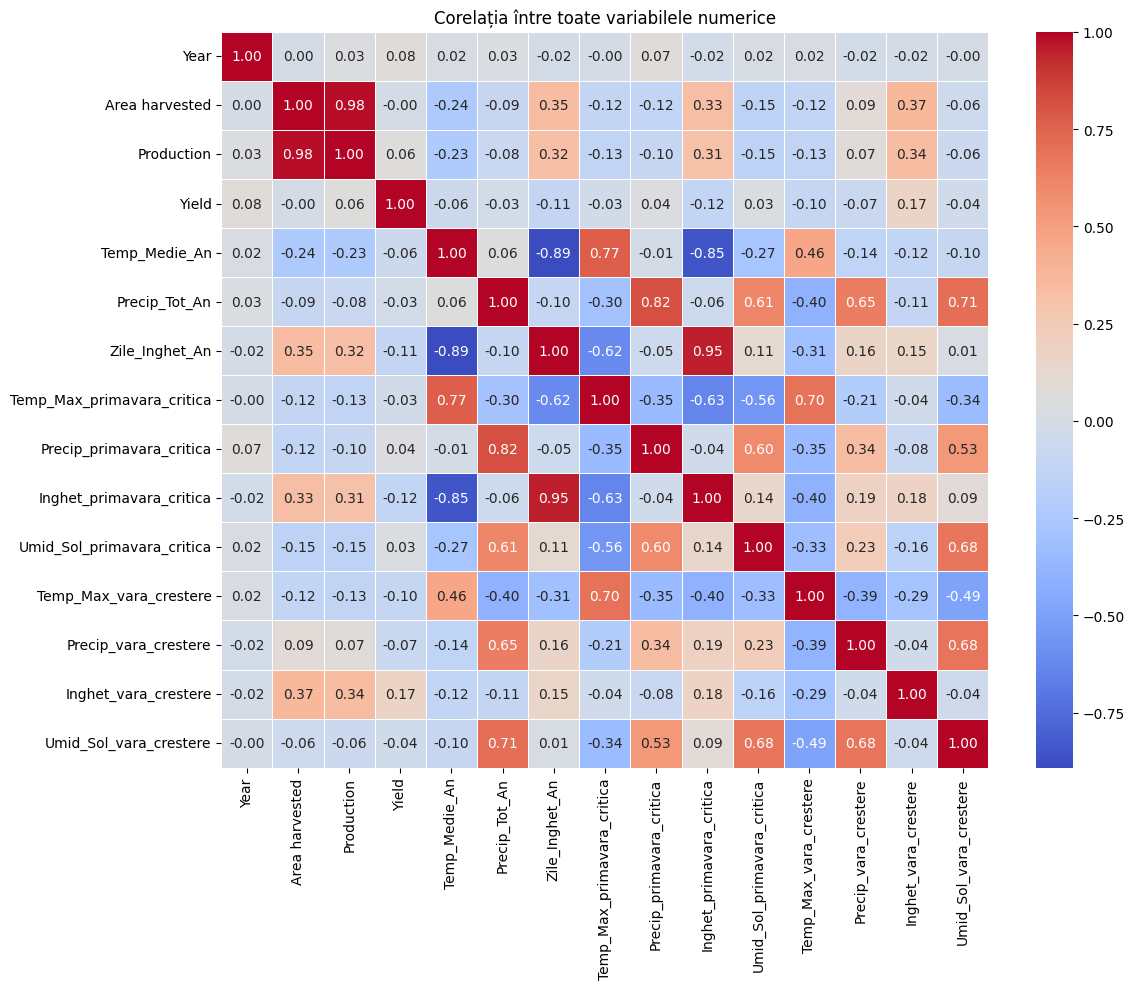

In [6]:
# Selectează automat doar coloanele numerice
corr = df.select_dtypes(include='number').corr()

# Heatmap
plt.figure(figsize=(12, 10))  # mărești figura dacă sunt multe coloane
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Corelația între toate variabilele numerice")
plt.tight_layout()
plt.show()

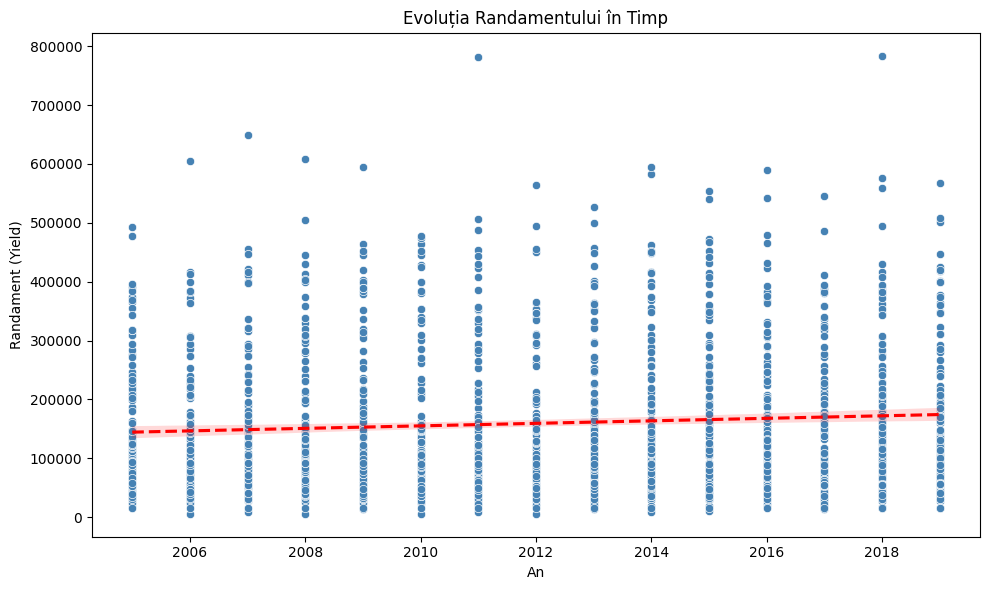

In [7]:
# Yield vs Year
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Year', y='Yield', color='steelblue')
sns.regplot(data=df, x='Year', y='Yield', scatter=False, color='red', 
            line_kws={'linestyle': '--'})
plt.title("Evoluția Randamentului în Timp")
plt.xlabel("An")
plt.ylabel("Randament (Yield)")
plt.tight_layout()
plt.show()


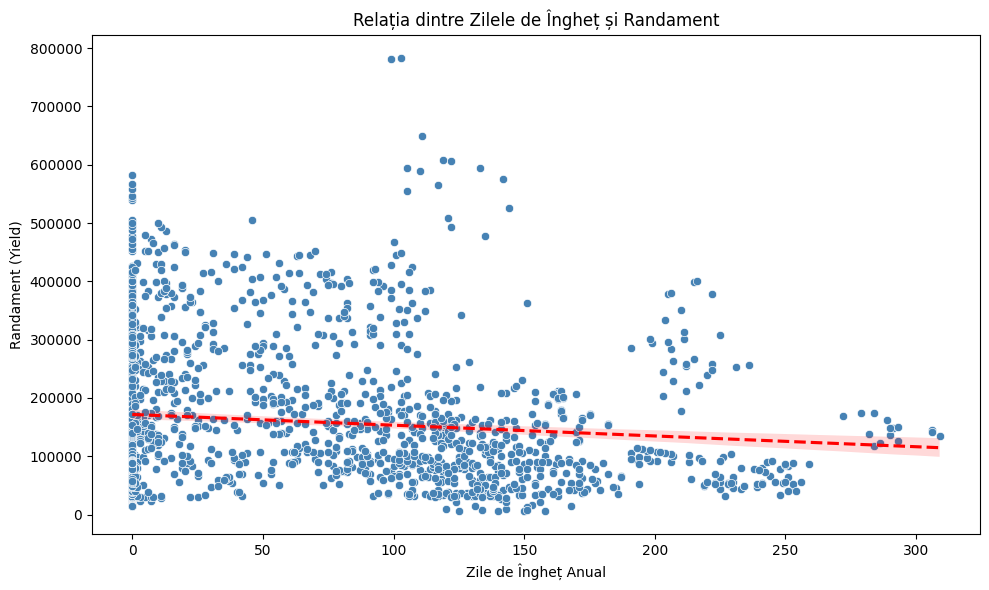

In [8]:
# Yield vs Zile_Inghet_An
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Zile_Inghet_An', y='Yield', color='steelblue')
sns.regplot(data=df, x='Zile_Inghet_An', y='Yield', scatter=False, color='red', 
            line_kws={'linestyle': '--'})
plt.title("Relația dintre Zilele de Îngheț și Randament")
plt.xlabel("Zile de Îngheț Anual")
plt.ylabel("Randament (Yield)")
plt.tight_layout()
plt.show()


In [31]:
df.head()

,Area,Year,Area harvested,Production,Yield,Temp_Medie_An,Precip_Tot_An,Zile_Inghet_An,Temp_Max_primavara_critica,Precip_primavara_critica,Inghet_primavara_critica,Umid_Sol_primavara_critica,Temp_Max_vara_crestere,Precip_vara_crestere,Inghet_vara_crestere,Umid_Sol_vara_crestere
0,Afghanistan,2005,2751.0,20239.0,73570.0,11.38,296.6,119.0,25.93,90.8,15.0,0.412,36.74,110.7,0.0,0.379
1,Afghanistan,2006,7000.0,52500.0,75000.0,12.38,420.0,99.0,32.83,92.3,15.0,0.444,36.12,93.2,0.0,0.359
2,Afghanistan,2007,7000.0,59500.0,85000.0,12.15,339.4,107.0,30.87,145.0,20.0,0.533,34.38,76.3,0.0,0.369
3,Afghanistan,2008,7000.0,56061.0,80087.0,12.04,418.9,89.0,31.84,166.8,1.0,0.428,34.73,133.8,0.0,0.388
4,Afghanistan,2009,8550.0,72765.0,85105.0,10.97,601.8,117.0,28.33,271.4,19.0,0.629,35.37,66.9,0.0,0.404


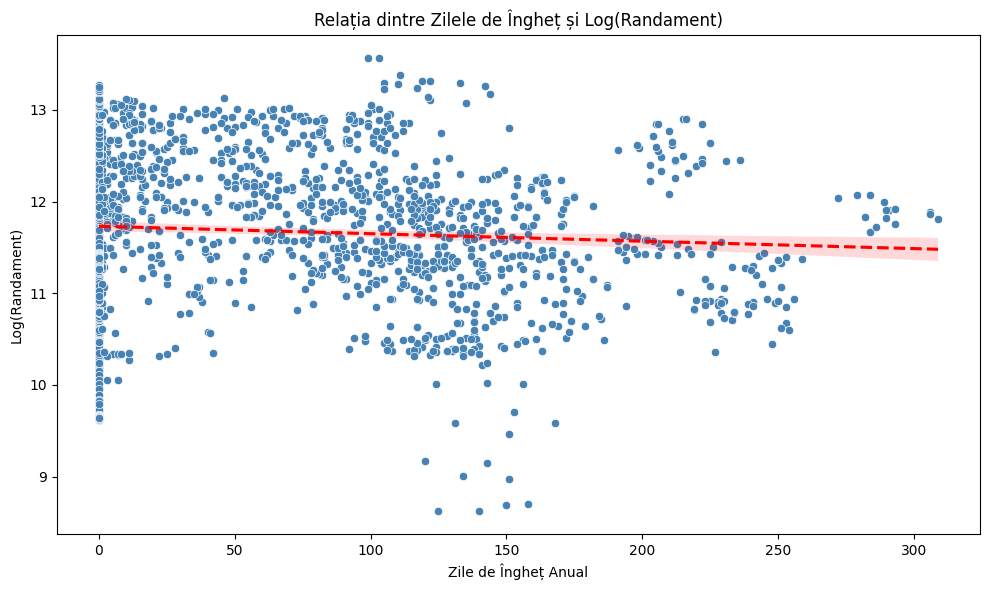

In [19]:
# Adaugă coloana log
df['Log_Yield'] = np.log1p(df['Yield'])  # log1p evită problemele cu valorile 0

# Scatter Log_Yield vs Zile_Inghet_An
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Zile_Inghet_An', y='Log_Yield', color='steelblue')
sns.regplot(data=df, x='Zile_Inghet_An', y='Log_Yield', scatter=False, color='red',
            line_kws={'linestyle': '--'})
plt.title("Relația dintre Zilele de Îngheț și Log(Randament)")
plt.xlabel("Zile de Îngheț Anual")
plt.ylabel("Log(Randament)")
plt.tight_layout()
plt.show()

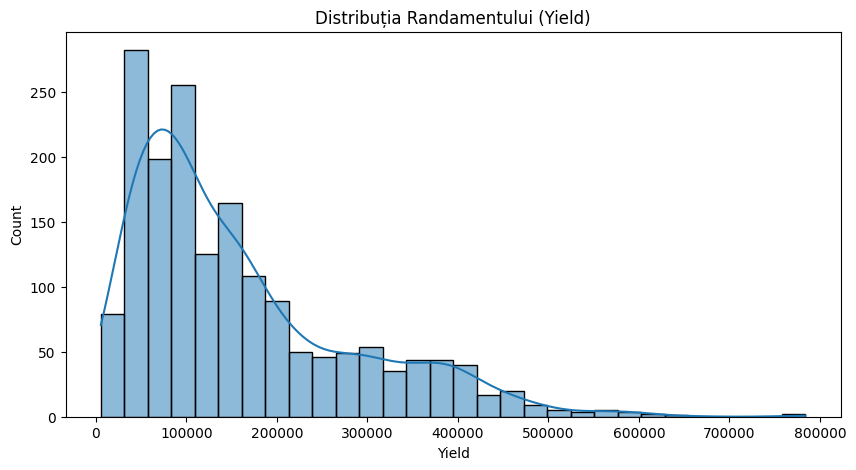

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Yield'], kde=True, bins=30)
plt.title("Distribuția Randamentului (Yield)")
plt.show()

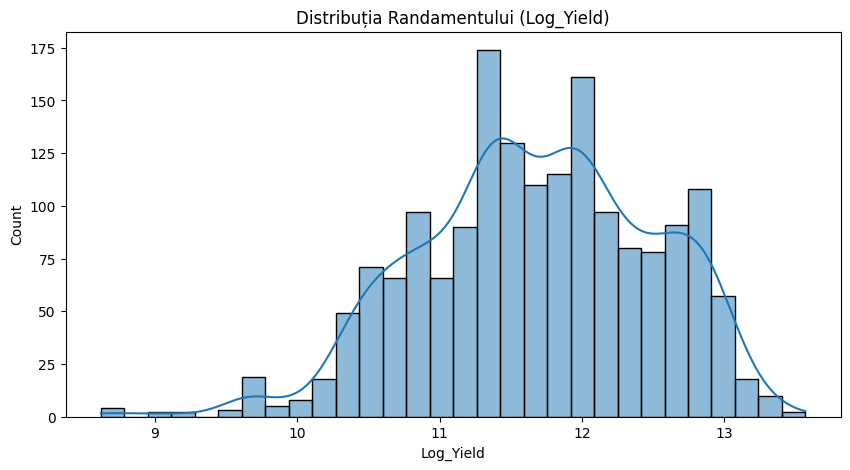

In [45]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Log_Yield'], kde=True, bins=30)
plt.title("Distribuția Randamentului (Log_Yield)")
plt.show()

Antrenarea si testarea Modelelor.

In [12]:

base_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Extra Trees": ExtraTreesRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "XGBoost": xgb.XGBRegressor()
}

param_grids = {
    "Linear Regression": {},
    "Ridge" : {
        "alpha" :  uniform(0.01,19.9)
    },
    "Lasso" : {
        "alpha" : uniform(0.01,19.9)
    },
    "Decision Tree": {
        'max_depth': [3, 5, 8, 12, 15, None],
        'min_samples_split': randint(2, 21),
        'min_samples_leaf': randint(1,5),
        'criterion': ['squared_error', 'friedman_mse']
    },
    "Random Forest": {
        'n_estimators': randint(100,801),
        'max_depth': [5, 8, 15, 25, None],
        'min_samples_leaf': randint(1,5),
        'max_features': [None, 'sqrt', 'log2'],
        'bootstrap': [True, False]
    },
    "Extra Trees": {
        'n_estimators': randint(400, 600),      # optim găsit: 478
        'max_depth': [15, 20, 25],              # optim găsit: 20
        'min_samples_split': randint(8, 15),    # optim găsit: 10
        'min_samples_leaf': randint(3, 6),      # optim găsit: 4
        'bootstrap': [False],                   # optim găsit: False - fix
        'max_features': [1.0, 'sqrt', 'log2']  # optim găsit: 1.0, testăm și altele
    },
    "Gradient Boosting": {
        'n_estimators': randint(100,1001),
        'learning_rate': uniform(0.001,0.099),
        'max_depth': randint(3,7),
        'subsample': uniform(0.6,0.4),
        'n_iter_no_change': [10]
    },
    "AdaBoost": {
        'n_estimators': randint(50,501),
        'learning_rate': uniform(0.01,0.99),
        'loss': ['linear', 'square', 'exponential']
    },
    "XGBoost": {
        'n_estimators':       randint(100, 1001),
        'learning_rate':      uniform(0.01, 0.09),
        'max_depth':          randint(3, 10),
        'subsample':          uniform(0.6, 0.4),
        'colsample_bytree':   uniform(0.6, 0.4),
        'gamma':              uniform(0, 0.2)
    }
}


# Sortează după Area apoi Year - fiecare țară e reprezentată în ambele seturi
df = df.sort_values(['Area', 'Year']).reset_index(drop=True)

X = df.drop(columns=['Yield', 'Production', 'Area harvested', 'Year', 'Log_Yield'], errors='ignore')
y = df['Yield']

encoder = BinaryEncoder(cols=['Area'])
X_encoded = encoder.fit_transform(X)

# Split per țară - 70% primii ani, 30% ultimii ani pentru fiecare țară
def time_split_by_area(df, test_ratio=0.3):
    train_idx, test_idx = [], []
    for area, group in df.groupby('Area'):
        n = len(group)
        split = int(n * (1 - test_ratio))
        train_idx.extend(group.index[:split])
        test_idx.extend(group.index[split:])
    return train_idx, test_idx

train_idx, test_idx = time_split_by_area(df)

x_train33 = X_encoded.loc[train_idx].reset_index(drop=True)
x_test33  = X_encoded.loc[test_idx].reset_index(drop=True)
y_train33 = y.loc[train_idx].reset_index(drop=True)
y_test33  = y.loc[test_idx].reset_index(drop=True)

# TimeSeriesSplit pentru cross-validation
tscv = TimeSeriesSplit(n_splits=5)


print(f"{'Model':<25} | {'Train R2':<10} | {'Test R2':<10} | {'Variance':<10} |  {'bias':<10}| {'MAE':<10}")
print("-" * 100)

results = {}

for name,base in base_models.items():
    params = param_grids[name]

    randomsearch = RandomizedSearchCV(base,params,n_iter=100, cv=tscv,scoring = 'r2',n_jobs=-1,random_state=42)
    model = randomsearch.fit(x_train33,y_train33)

    predictions = model.predict(x_test33)

    train_r2 = model.score(x_train33, y_train33)
    r2 = model.score(x_test33, y_test33)

    bias     = abs(1 - train_r2)
    variance = max(0, train_r2 - r2)
    mae = metrics.mean_absolute_error(y_test33, predictions)


    print(f"{name:<20}   | {train_r2:.4f}   |   {r2:.4f}   |  {variance:.4f}    |   {bias:.2f}   |   {mae:.2f}" )

    results[name] = {
        "model": model.best_estimator_,
        "r2": r2,
        "mae": mae
    }
    # Verifici ce parametri a ales modelul
print(results["Extra Trees"]["model"].get_params())

Model                     | Train R2   | Test R2    | Variance   |  bias      | MAE       
----------------------------------------------------------------------------------------------------


c:\Users\apop3\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 1 is smaller than n_iter=100. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Linear Regression      | 0.2600   |   0.2235   |  0.0365    |   0.74   |   85316.30
Ridge                  | 0.2551   |   0.2228   |  0.0322    |   0.74   |   85623.36
Lasso                  | 0.2600   |   0.2235   |  0.0365    |   0.74   |   85316.63
Decision Tree          | 0.1874   |   0.1618   |  0.0256    |   0.81   |   87652.99
Random Forest          | 0.9190   |   0.7411   |  0.1779    |   0.08   |   47239.45
Extra Trees            | 0.8805   |   0.7834   |  0.0971    |   0.12   |   44199.35
AdaBoost               | 0.2537   |   0.2431   |  0.0106    |   0.75   |   94312.37
XGBoost                | 0.8798   |   0.6947   |  0.1851    |   0.12   |   51964.97
{'bootstrap': False, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 25, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 14, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 546, 'n_jobs': None, 'o

Alegem primele 3 cele mai bune modele.

In [13]:
top3_names = sorted(results, key=lambda x: results[x]["r2"], reverse=True)[:3]

print("\nTop 3 modele selectate:")
for name in top3_names:
    print(f"  {name:<25} | R2: {results[name]['r2']:.4f} | MAE: {results[name]['mae']:.2f}")

top3_estimators = [(name, results[name]["model"]) for name in top3_names]


Top 3 modele selectate:
  Extra Trees               | R2: 0.7834 | MAE: 44199.35
  Random Forest             | R2: 0.7411 | MAE: 47239.45
  XGBoost                   | R2: 0.6947 | MAE: 51964.97


Facem media rezultatelor celor 3 modele alese.

In [14]:

preds_list = [results[name]["model"].predict(x_test33) for name in top3_names]
avg_preds  = np.mean(preds_list, axis=0)
avg_r2     = metrics.r2_score(y_test33, avg_preds)
avg_mae    = metrics.mean_absolute_error(y_test33, avg_preds)

print(f"Averaging | R2: {avg_r2:.4f} | MAE: {avg_mae:.2f}")

Averaging | R2: 0.7477 | MAE: 47421.93


Se alege modelul cel mai bun printr-un sistem de voting.

In [15]:
top3_estimators = [(name, results[name]["model"]) for name in top3_names]
weights = [results[name]["r2"] for name in top3_names]

voting = VotingRegressor(estimators=top3_estimators, weights=weights)
voting.fit(x_train33, y_train33)

v_preds = voting.predict(x_test33)
v_r2    = metrics.r2_score(y_test33, v_preds)
v_mae   = metrics.mean_absolute_error(y_test33, v_preds)

print(f"Voting Weighted | R2: {v_r2:.4f} | MAE: {v_mae:.2f}")

Voting Weighted | R2: 0.7484 | MAE: 47327.58


In [16]:
best_name = max(results, key=lambda x: results[x]["r2"])
best_model = results[best_name]["model"]

preds = best_model.predict(x_test33)
print(f"Model final: {best_name}")
print(f"R2:  {metrics.r2_score(y_test33, preds):.4f}")
print(f"MAE: {metrics.mean_absolute_error(y_test33, preds):.2f}")

Model final: Extra Trees
R2:  0.7834
MAE: 44199.35


Feature importance. 

Grupăm coloanele care reprezinta tările intr-una singura numita Area pentru a observa mai usor importanta fiecarei variabile.

Area (tara)                   0.432475
Temp_Medie_An                 0.085820
Temp_Max_vara_crestere        0.066717
Zile_Inghet_An                0.064593
Umid_Sol_primavara_critica    0.056948
Umid_Sol_vara_crestere        0.048431
Precip_Tot_An                 0.046312
Inghet_primavara_critica      0.045530
Inghet_vara_crestere          0.044090
Precip_vara_crestere          0.041976
Temp_Max_primavara_critica    0.038098
Precip_primavara_critica      0.029011
dtype: float64


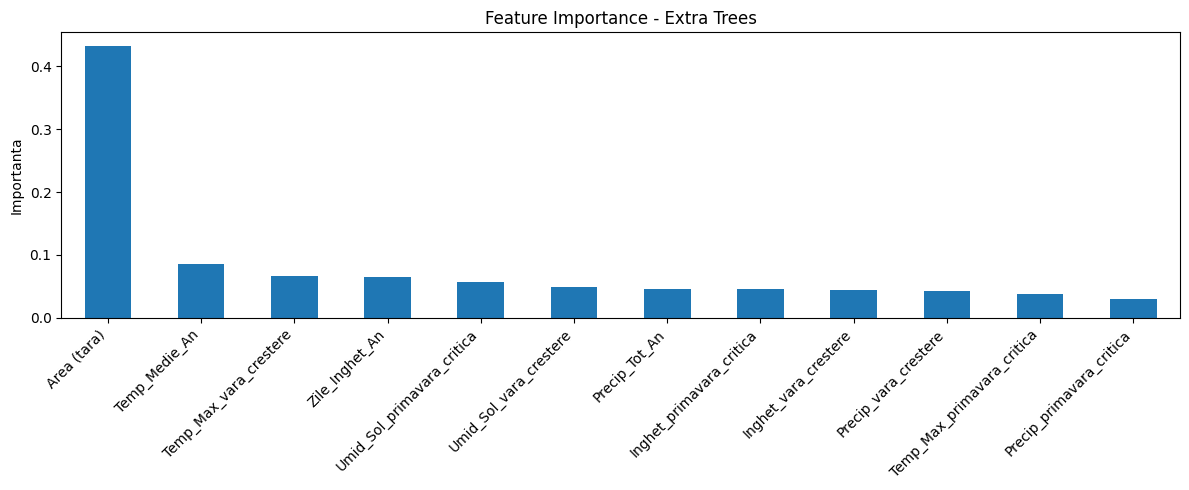

<class 'sklearn.ensemble._forest.ExtraTreesRegressor'>


In [ ]:
# Feature importance cu grupare Area
importances = pd.Series(
    best_model.feature_importances_,
    index=x_train33.columns
).sort_values(ascending=False)

# Suma importantelor pentru toate coloanele Area
area_importance = importances[importances.index.str.startswith('Area')].sum()

# Restul variabilelor fara Area
importances_clean = importances[~importances.index.str.startswith('Area')].copy()

# Adaugi Area ca o singura valoare
importances_clean['Area (tara)'] = area_importance
importances_clean = importances_clean.sort_values(ascending=False)

print(importances_clean)

# Grafic
importances_clean.plot(kind='bar', figsize=(12, 5), title='Feature Importance - Extra Trees')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Importanta')
plt.tight_layout()
plt.show()

Facem un test și încercăm să prezicem randamentul tarilor  din Europa.


Facem o medie a datelor climatice pe anii precedenti pentru a avea date de input ca să prezicem pe un an viitor. Deoarece nu avem date doar pana in 2019 nu putem spune neaparat ca predictia se face pe anul 2026. Teoretic ar fi corect sa zicem ca se face pe 2020.

                                                    Tara  Randament estimat (hg/ha)  Echivalent (tone/ha)
1                                            Switzerland                     494403                 49.44
2                                                  Italy                     344292                 34.43
3                                               Slovenia                     341232                 34.12
4                                            Netherlands                     337620                 33.76
5                                                 France                     332448                 33.24
6                                                Belgium                     325698                 32.57
7                                                Ireland                     247644                 24.76
8                                                Germany                     241353                 24.14
9                                             

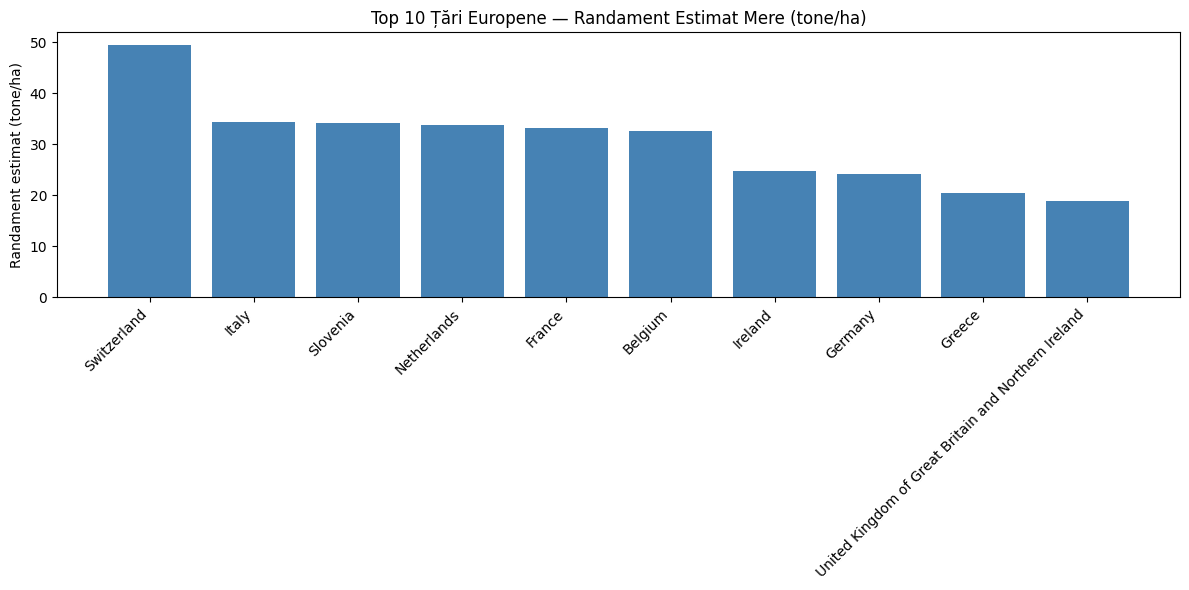

In [21]:
tari_europa = [
    'Switzerland', 'Netherlands', 'France', 'Italy', 'Slovenia',
    'Belgium', 'Germany', 'Ireland', 'Greece', 'Denmark',
    'United Kingdom of Great Britain and Northern Ireland',
    'Austria', 'Spain', 'Montenegro', 'Portugal', 'Hungary',
    'Sweden', 'Luxembourg', 'Poland', 'Czechia', 'Serbia',
    'Slovakia', 'Croatia', 'Romania', 'North Macedonia',
    'Ukraine', 'Azerbaijan', 'Bulgaria', 'Cyprus', 'Belarus',
    'Norway', 'Georgia', 'Lithuania', 'Latvia', 'Estonia',
    'Bosnia and Herzegovina', 'Finland', 'Russian Federation',
    'Republic of Moldova', 'Albania', 'Turkey'
]

podium_europa = []

for tara in tari_europa:
    if tara not in df['Area'].values:
        continue
        
    tara_mean = df[df['Area'] == tara].drop(
        columns=['Yield', 'Production', 'Area harvested', 
                 'Year', 'Log_Yield', 'Area'], 
        errors='ignore'
    ).mean()
    
    new_data = pd.DataFrame([tara_mean])
    new_data['Area'] = tara
    
    new_data_encoded = encoder.transform(new_data)
    new_data_encoded = new_data_encoded[x_train33.columns]
    
    predicted_yield = results["Extra Trees"]["model"].predict(new_data_encoded)
    
    podium_europa.append({
        'Tara': tara,
        'Randament estimat (hg/ha)': round(predicted_yield[0]),
        'Echivalent (tone/ha)': round(predicted_yield[0] / 10000, 2)
    })

podium_europa_df = pd.DataFrame(podium_europa).sort_values(
    'Randament estimat (hg/ha)', ascending=False
).reset_index(drop=True)

podium_europa_df.index += 1

print(podium_europa_df.to_string())

# Grafic top 10
plt.figure(figsize=(12, 6))
top10 = podium_europa_df.head(10)
plt.bar(top10['Tara'], top10['Echivalent (tone/ha)'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Țări Europene — Randament Estimat Mere (tone/ha)')
plt.ylabel('Randament estimat (tone/ha)')
plt.tight_layout()
plt.show()

Facem o verficare sa vedem mediile reale pentru cateva tari ca sa verificam daca rezultatele noastre difera foarte mult sau nu.

In [22]:
for tara in ['Netherlands', 'France', 'Italy', 'Romania', 'Poland']:
    mean_yield = df[df['Area'] == tara]['Yield'].mean()
    print(f"{tara:<15} | Media reala: {mean_yield:,.0f} hg/ha | {mean_yield/10000:.2f} tone/ha")

Netherlands     | Media reala: 409,336 hg/ha | 40.93 tone/ha
France          | Media reala: 388,431 hg/ha | 38.84 tone/ha
Italy           | Media reala: 404,890 hg/ha | 40.49 tone/ha
Romania         | Media reala: 90,639 hg/ha | 9.06 tone/ha
Poland          | Media reala: 154,501 hg/ha | 15.45 tone/ha
